# Четвертая лабораторная работа

## Установка и импорт необходимых библиотек

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns; sns.set()
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix


## Загрузка и подготовка данных

In [3]:
df = pd.read_csv('cars_moldova_clean.csv', delimiter=',')
num_columns = ['Year', 'Distance', 'Engine_capacity(cm3)', 'Price(euro)', 'km_year']
df_num = df[num_columns].copy()

## Реализация логистической регрессии

Создадим класс для логистической регрессии с поддержкой регуляризации.

In [4]:
_EPS_ = 1e-6

class LogisticRegression_Custom:
    def __init__(self, learning_rate=0.5, epochs=100, threshold=0.5, batch_size=1000, random_state=42):
        self.learning_rate = learning_rate/2
        self.epochs = epochs
        self.threshold = threshold
        self.batch_size = batch_size
        self.random_state = random_state
        self.weights = None
        self.bias = None
    
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def add_bias(self, X):
        return np.c_[np.ones(X.shape[0]), X]
    
    def forward(self, X):        
        return self.sigmoid(self.weights.dot(X.T))
    
    def to_class(self, logit):
        return (logit >= self.threshold) * 1
    
    def fit(self, X, y):
        X = self.add_bias(X)
        n_samples, n_features = X.shape
        
        if self.weights is None:
            np.random.seed(self.random_state)
            self.weights = np.random.randn(n_features)
        
        for _ in range(self.epochs):
            yhat = self.forward(X)
            gradient = X.T.dot(yhat - y) / n_samples
            self.weights -= self.learning_rate * gradient
            
    def predict(self, X):
        yhat = self.forward(self.add_bias(X))
        return self.to_class(yhat)
    
    def score(self, X, y):
        yhat = self.predict(X)
        return sum((yhat==y)*1)/y.size

## Обучение модели

Подготовим данные и обучим модель логистической регрессии.

In [7]:
# Создание бинарной целевой переменной на основе цены
median_price = df['Price(euro)'].median()
df['high_price'] = (df['Price(euro)'] > median_price).astype(int)

# Подготовка признаков
numeric_features = ['Year', 'Distance', 'Engine_capacity(cm3)']
X = df[numeric_features].copy()
X = (X - X.mean()) / X.std()
y = df['high_price']

# Разделение на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Создание и обучение модели
model = LogisticRegression_Custom(learning_rate=0.5, epochs=100)
model.fit(X_train, y_train)

# Оценка точности
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)
print(f'Точность на обучающей выборке: {train_accuracy:.4f}')
print(f'Точность на тестовой выборке: {test_accuracy:.4f}')

Точность на обучающей выборке: 0.8532
Точность на тестовой выборке: 0.8422


## Визуализация результатов

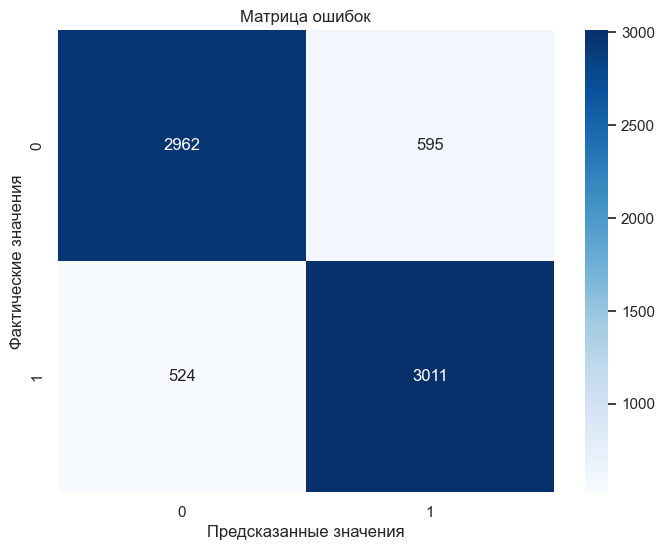

In [10]:
# Получение предсказаний
y_pred = model.predict(X_test)

# Построение матрицы ошибок
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок')
plt.xlabel('Предсказанные значения')
plt.ylabel('Фактические значения')
plt.show()

In [12]:
regr = LogisticRegression_Custom(learning_rate=0.8,epochs=1500,batch_size=5000)

regr.fit(X_train, y_train)

regr.plot_cost()

print( 'train Accuracy: %.4f; test Accuracy: %.4f' % (regr.score(X_train, y_train), regr.score(X_test, y_test)))

regr.classification_report(X_test, y_test)

AttributeError: 'LogisticRegression_Custom' object has no attribute 'plot_cost'

# Контрольные вопросы

Вопрос 1: 
**Что такое логистическая регрессия?**
- Ответ: Логистическая регрессия - это метод классификации, который предсказывает вероятность принадлежности объекта к определенному классу.

Вопрос 2:
**В чем отличие логистической регрессии от линейной?**
- Ответ: Линейная регрессия предсказывает непрерывные значения, а логистическая регрессия предсказывает вероятности принадлежности к классам.

Вопрос 3:
**Какие метрики используются для оценки качества логистической регрессии?**
- Ответ: Основные метрики: accuracy (точность), precision (точность), recall (полнота), F1-score (F1-мера), ROC-AUC.

Вопрос 4:
**Что показывают коэффициенты логистической регрессии?**
- Ответ: Коэффициенты показывают влияние каждого признака на вероятность принадлежности к классу.